<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab6_Final_Project_Data_0518.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 6 - Final Project Data Analysis Template and Architecture Design

**Date:** Monday, 18 May 2026  
**Goal:** use this notebook as a template for the final project.

This notebook demonstrates a complete project structure:

1. state the project question;
2. load and inspect data;
3. write a data dictionary;
4. perform EDA;
5. split data into train, validation, and test sets;
6. compare baseline, linear, ridge, and neural-network models;
7. select variables using validation data;
8. evaluate the final candidates on the test set;
9. generate a report template and architecture blueprint.

Replace the example dataset with your own dataset when you start your final project.

## 0. Colab and Visual Studio Code setup

### Colab
Upload the CSV and JSON files directly to the Colab file panel, or put them in Google Drive:

```text
/content/
/content/data/
/content/drive/MyDrive/AKHU_labs/
```

### Visual Studio Code
Open the whole project folder, not just the notebook file. A good structure is:

```text
final_project/
    data/
        AKHU_lab6_final_project_student_success.csv
        AKHU_lab6_final_project_config.json
    outputs/
    models/
    notebooks/
```

Run the next cell to see where Python is currently working.

In [1]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFiles in current folder:")
for item in sorted(Path.cwd().glob("*"))[:30]:
    print(" ", item)

Current working directory:
/content

Files in current folder:
  /content/.config
  /content/AKHU_lab6_final_project_config.json
  /content/AKHU_lab6_final_project_student_success.csv
  /content/sample_data


## 1. Import packages

This template uses standard data-analysis packages:

- `pandas` for tables;
- `numpy` for numerical arrays;
- `matplotlib` for plots;
- `scikit-learn` for regression, ridge regression, train/test split, scaling, and neural network regression.

In Colab these packages are usually already installed. In Visual Studio Code, install them if needed:

```bash
pip install pandas numpy matplotlib scikit-learn
```

In [2]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"font.size": 11})

## 2. Reusable file finder

Use this function to reduce path errors in Colab and Visual Studio Code.

In [3]:
CANDIDATE_DIRS = [
    Path("data"),
    Path("."),
    Path("/content"),
    Path("/content/data"),
    Path("/content/drive/MyDrive/AKHU_labs"),
]

def find_file(filename):
    print("Current working directory:", Path.cwd())
    print("Searching for:", filename)
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        print("Checking:", candidate)
        if candidate.exists():
            print("Found:", candidate)
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Put it in data/, the notebook folder, /content, "
        "or /content/drive/MyDrive/AKHU_labs."
    )

DATA_FILE = "AKHU_lab6_final_project_student_success.csv"
CONFIG_FILE = "AKHU_lab6_final_project_config.json"

data_path = find_file(DATA_FILE)
config_path = find_file(CONFIG_FILE)

Current working directory: /content
Searching for: AKHU_lab6_final_project_student_success.csv
Checking: data/AKHU_lab6_final_project_student_success.csv
Checking: AKHU_lab6_final_project_student_success.csv
Found: AKHU_lab6_final_project_student_success.csv
Current working directory: /content
Searching for: AKHU_lab6_final_project_config.json
Checking: data/AKHU_lab6_final_project_config.json
Checking: AKHU_lab6_final_project_config.json
Found: AKHU_lab6_final_project_config.json


## 3. Load the project configuration and dataset

The JSON config stores the project title, target variable, candidate features, split strategy, and required outputs.

In [4]:
with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)

print(json.dumps(config, indent=2))

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

{
  "project_title": "Student Success Prediction System",
  "problem_statement": "Predict final_score from study behavior and prior performance variables.",
  "target": "final_score",
  "candidate_features": [
    "hours_studied",
    "quiz_average",
    "attendance_rate",
    "assignments_submitted",
    "login_count",
    "previous_score",
    "sleep_hours",
    "screen_time_hours"
  ],
  "required_outputs": [
    "EDA summary",
    "train_validation_test_split",
    "model_comparison_table",
    "final_model_choice",
    "architecture_blueprint",
    "limitations"
  ],
  "recommended_metrics": [
    "MAE",
    "RMSE",
    "baseline_relative_R2"
  ],
  "split_strategy": {
    "train": 0.7,
    "validation": 0.15,
    "test": 0.15,
    "random_state": 42
  }
}
Shape: (120, 10)


,student_id,hours_studied,quiz_average,attendance_rate,assignments_submitted,login_count,previous_score,sleep_hours,screen_time_hours,final_score
0,S001,1.45,58.3,0.69,8,8,73.3,5.3,2.8,63.3
1,S002,3.19,74.2,0.73,7,19,71.0,6.7,2.5,72.6
2,S003,3.15,71.1,0.72,8,15,55.7,7.5,3.2,67.0
3,S004,5.43,94.6,0.65,10,21,79.3,5.8,0.6,86.8
4,S005,5.22,88.5,0.95,8,19,86.9,8.4,3.1,82.0


## 4. Project sentence and data dictionary

Fill in these values for your own project later. The example values are from the student-success sample dataset.

In [5]:
project_title = config["project_title"]
target_col = config["target"]
feature_candidates = config["candidate_features"]

print("Project title:", project_title)
print("Target variable:", target_col)
print("Candidate features:")
for feature in feature_candidates:
    print(" -", feature)

print("\nProject sentence:")
print(f"This project predicts {target_col} from {', '.join(feature_candidates[:4])}, and other candidate variables.")

Project title: Student Success Prediction System
Target variable: final_score
Candidate features:
 - hours_studied
 - quiz_average
 - attendance_rate
 - assignments_submitted
 - login_count
 - previous_score
 - sleep_hours
 - screen_time_hours

Project sentence:
This project predicts final_score from hours_studied, quiz_average, attendance_rate, assignments_submitted, and other candidate variables.


In [6]:
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "role": ["ID" if c == "student_id" else ("target" if c == target_col else "feature") for c in df.columns],
    "example_value": [df[c].iloc[0] for c in df.columns],
})
data_dictionary

,column,role,example_value
0,student_id,ID,S001
1,hours_studied,feature,1.45
2,quiz_average,feature,58.3
3,attendance_rate,feature,0.69
4,assignments_submitted,feature,8
5,login_count,feature,8
6,previous_score,feature,73.3
7,sleep_hours,feature,5.3
8,screen_time_hours,feature,2.8
9,final_score,target,63.3


## 5. Basic inspection and missing values

Before modeling, check the data shape, data types, summary statistics, and missing values.

In [7]:
print("Rows and columns:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

summary = df[feature_candidates + [target_col]].describe().T
summary

Rows and columns: (120, 10)

Data types:
student_id                object
hours_studied            float64
quiz_average             float64
attendance_rate          float64
assignments_submitted      int64
login_count                int64
previous_score           float64
sleep_hours              float64
screen_time_hours        float64
final_score              float64
dtype: object

Missing values:
student_id               0
hours_studied            0
quiz_average             0
attendance_rate          0
assignments_submitted    0
login_count              0
previous_score           0
sleep_hours              0
screen_time_hours        0
final_score              0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
hours_studied,120.0,3.814417,1.560014,1.25,2.5050,3.895,5.2225,6.47
quiz_average,120.0,79.794167,13.097638,46.80,70.8000,80.350,90.5500,100.00
attendance_rate,120.0,0.776583,0.101712,0.55,0.7075,0.770,0.8400,1.00
assignments_submitted,120.0,8.100000,1.305451,5.00,7.0000,8.000,9.0000,10.00
login_count,120.0,18.116667,4.449876,8.00,15.0000,18.000,21.0000,29.00
previous_score,120.0,75.040000,11.396575,40.90,67.1500,74.000,84.4500,95.00
sleep_hours,120.0,6.779167,0.860222,4.70,6.1750,6.900,7.3000,9.10
screen_time_hours,120.0,3.563333,1.300416,0.60,2.8000,3.550,4.4250,6.80
final_score,120.0,74.605833,11.532434,49.40,65.6500,74.800,83.5500,98.30


## 6. EDA figures

A final project should include at least one distribution plot and at least one relationship plot.

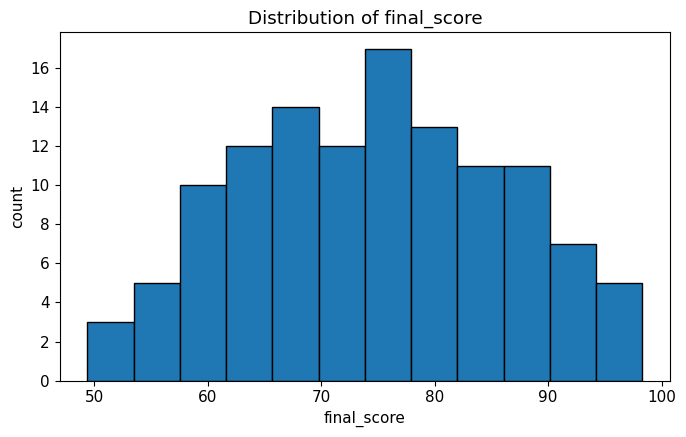

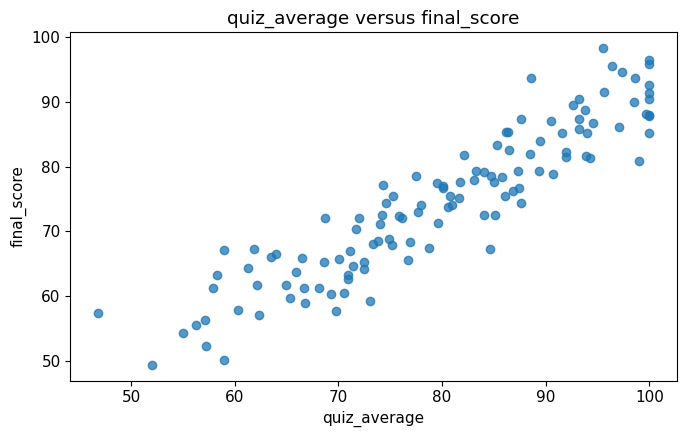

In [8]:
OUTPUTS_DIR = Path("outputs")
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4.5))
plt.hist(df[target_col], bins=12, edgecolor="black")
plt.title("Distribution of final_score")
plt.xlabel(target_col)
plt.ylabel("count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.scatter(df["quiz_average"], df[target_col], alpha=0.75)
plt.title("quiz_average versus final_score")
plt.xlabel("quiz_average")
plt.ylabel(target_col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quiz_average_vs_final_score.png", dpi=160)
plt.show()

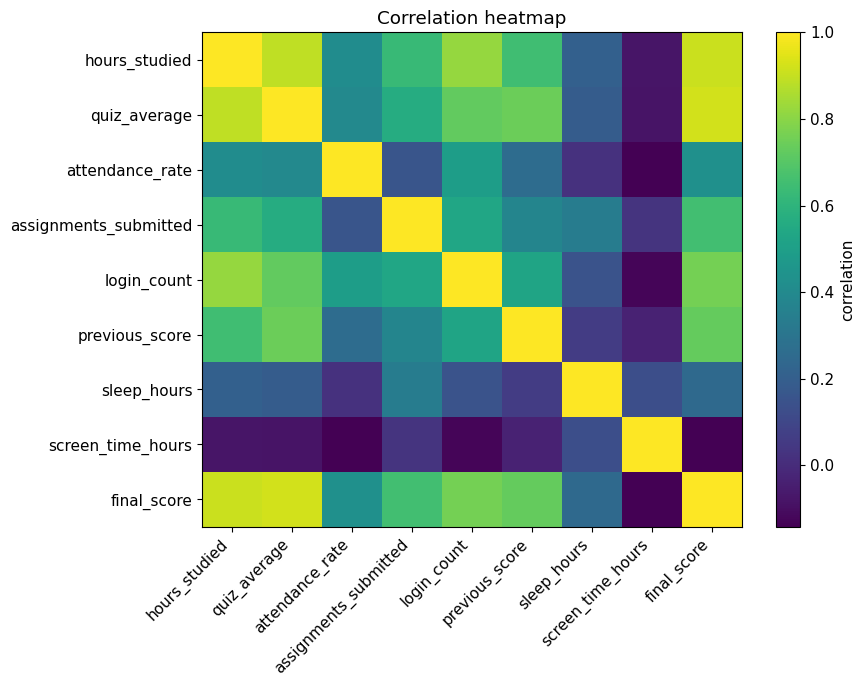

In [9]:
corr = df[feature_candidates + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=160)
plt.show()

## 7. Train, validation, and test split

Use training data to fit models, validation data to select variables and choose model settings, and test data for the final honest comparison.

In [10]:
X = df[feature_candidates]
y = df[target_col]

train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1765, random_state=42)

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

Train rows: 83
Validation rows: 19
Test rows: 18


## 8. Evaluation functions

The baseline-relative R-squared compares the model against the mean baseline on the same test rows.

In [11]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def r2_vs_baseline(y_true, y_pred, baseline_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    baseline_pred = np.asarray(baseline_pred, dtype=float)
    sse_model = np.sum((y_true - y_pred) ** 2)
    sse_base = np.sum((y_true - baseline_pred) ** 2)
    if np.isclose(sse_base, 0):
        return np.nan
    return float(1 - sse_model / sse_base)

## 9. Validation-based variable selection

This simple forward-selection method chooses predictors using validation RMSE. The test set is not used for feature selection.

In [12]:
def forward_select_features(train_df, val_df, feature_pool, target_col):
    selected = []
    remaining = list(feature_pool)
    best_rmse = float("inf")
    history = []

    while remaining:
        trial_results = []
        for feature in remaining:
            trial_features = selected + [feature]
            model = LinearRegression()
            model.fit(train_df[trial_features], train_df[target_col])
            pred = model.predict(val_df[trial_features])
            trial_rmse = rmse(val_df[target_col], pred)
            trial_results.append((trial_rmse, feature, trial_features))

        trial_results.sort(key=lambda item: item[0])
        candidate_rmse, candidate_feature, candidate_features = trial_results[0]

        if candidate_rmse < best_rmse - 1e-6:
            selected = candidate_features
            remaining.remove(candidate_feature)
            best_rmse = candidate_rmse
            history.append({
                "step": len(selected),
                "added_feature": candidate_feature,
                "validation_RMSE": best_rmse,
                "selected_features": ", ".join(selected),
            })
        else:
            break

    return selected, pd.DataFrame(history)

selected_features, selection_history = forward_select_features(train_df, val_df, feature_candidates, target_col)
print("Selected features:", selected_features)
selection_history

Selected features: ['quiz_average', 'assignments_submitted', 'hours_studied', 'sleep_hours', 'previous_score']


,step,added_feature,validation_RMSE,selected_features
0,1,quiz_average,4.534332,quiz_average
1,2,assignments_submitted,4.053728,"quiz_average, assignments_submitted"
2,3,hours_studied,3.756850,"quiz_average, assignments_submitted, hours_stu..."
3,4,sleep_hours,3.687007,"quiz_average, assignments_submitted, hours_stu..."
4,5,previous_score,3.654359,"quiz_average, assignments_submitted, hours_stu..."


## 10. Ridge regression: why it is included

Ridge regression is still a **linear model**. It predicts with

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_px_p.
$$

The difference is how the coefficients are learned.

Ordinary least squares minimizes squared error:

$$
\min_{\beta}\sum_i (y_i - \hat{y}_i)^2.
$$

Ridge regression minimizes squared error plus an **L2 penalty**:

$$
\min_{\beta}\left[\sum_i (y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^p \beta_j^2\right].
$$

The L2 penalty discourages very large coefficients. This can help when predictors are correlated. In this project, variables such as `hours_studied`, `quiz_average`, `previous_score`, and `login_count` may contain overlapping information.

### Why ridge may work best here

- It keeps all features, so it does not throw away useful information.
- It shrinks unstable coefficients, which can reduce variance.
- It helps when the linear regression matrix is singular or nearly singular because of collinearity.
- It may improve test-set performance, even if it adds a small amount of bias.

Important: ridge is not automatically best. We still decide by validation and test-set evaluation.


In [13]:
# Ridge diagnostic: correlation and condition number
# This cell helps explain why ridge can be useful when predictors are correlated.

trainval_df = pd.concat([train_df, val_df], ignore_index=True)
y_trainval = trainval_df[target_col]
y_test = test_df[target_col]

# 1. Show the strongest feature-feature correlations.
feature_corr = trainval_df[feature_candidates].corr(numeric_only=True).abs()
upper_pairs = []
for i, left in enumerate(feature_candidates):
    for right in feature_candidates[i+1:]:
        upper_pairs.append({
            "feature_1": left,
            "feature_2": right,
            "absolute_correlation": feature_corr.loc[left, right],
        })

correlation_pairs_df = pd.DataFrame(upper_pairs).sort_values("absolute_correlation", ascending=False)
print("Most correlated feature pairs:")
display(correlation_pairs_df.head(8))

# 2. Compare the numerical stability of X^T X and X^T X + alpha I.
# A large condition number means the matrix is more unstable.
scaler_for_diagnostic = StandardScaler()
X_scaled = scaler_for_diagnostic.fit_transform(trainval_df[feature_candidates])
gram_matrix = X_scaled.T @ X_scaled
alpha = 1.0
ridge_matrix = gram_matrix + alpha * np.eye(len(feature_candidates))

condition_table = pd.DataFrame({
    "matrix": ["X.T @ X (OLS normal-equation matrix)", "X.T @ X + alpha I (ridge matrix)"],
    "condition_number": [np.linalg.cond(gram_matrix), np.linalg.cond(ridge_matrix)],
})

display(condition_table)
print("Interpretation: ridge usually lowers the condition number, so the coefficient calculation is more stable.")

Most correlated feature pairs:


,feature_1,feature_2,absolute_correlation
0,hours_studied,quiz_average,0.890266
3,hours_studied,login_count,0.822518
10,quiz_average,previous_score,0.740872
9,quiz_average,login_count,0.720594
4,hours_studied,previous_score,0.645779
2,hours_studied,assignments_submitted,0.604508
8,quiz_average,assignments_submitted,0.551898
18,assignments_submitted,login_count,0.533955


,matrix,condition_number
0,X.T @ X (OLS normal-equation matrix),46.722241
1,X.T @ X + alpha I (ridge matrix),41.840692


Interpretation: ridge usually lowers the condition number, so the coefficient calculation is more stable.


## 11. Candidate models and final test-set comparison

After variable selection, refit each candidate on the combined training + validation data. Then evaluate on the test set. This comparison now includes full linear regression and ridge regression with all features, so students can see the benefit of regularization when features are correlated.

In [14]:
# Candidate models and final test-set comparison
# Train/validation data are combined only after variable selection is finished.

trainval_df = pd.concat([train_df, val_df], ignore_index=True)
y_trainval = trainval_df[target_col]
y_test = test_df[target_col]

baseline_value = float(y_trainval.mean())
baseline_test_pred = np.full(len(test_df), baseline_value)

model_specs = [
    {"name": "Mean baseline", "features": [], "model": None},
    {"name": "Linear: quiz only", "features": ["quiz_average"], "model": LinearRegression()},
    {"name": "Linear: hours + quiz", "features": ["hours_studied", "quiz_average"], "model": LinearRegression()},
    {"name": "Selected linear", "features": selected_features, "model": LinearRegression()},
    {"name": "Full linear: all features", "features": feature_candidates, "model": LinearRegression()},
    {"name": "Ridge: all features", "features": feature_candidates, "model": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    )},
    {"name": "Neural network: all features", "features": feature_candidates, "model": make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(16,), max_iter=2500, random_state=42, early_stopping=True)
    )},
]

results = []
predictions = {}
trained_models = {}
for spec in model_specs:
    name = spec["name"]
    features = spec["features"]
    model = spec["model"]

    if name == "Mean baseline":
        pred = baseline_test_pred
    else:
        model.fit(trainval_df[features], y_trainval)
        pred = model.predict(test_df[features])
        trained_models[name] = model

    predictions[name] = pred
    results.append({
        "model": name,
        "features": ", ".join(features) if features else "none",
        "test_MAE": mae(y_test, pred),
        "test_RMSE": rmse(y_test, pred),
        "test_R2_vs_baseline": r2_vs_baseline(y_test, pred, baseline_test_pred),
    })

results_df = pd.DataFrame(results).sort_values("test_RMSE")
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2500) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,features,test_MAE,test_RMSE,test_R2_vs_baseline
5,Ridge: all features,"hours_studied, quiz_average, attendance_rate, ...",2.703798,3.439329,0.931053
4,Full linear: all features,"hours_studied, quiz_average, attendance_rate, ...",2.736033,3.455039,0.930422
3,Selected linear,"quiz_average, assignments_submitted, hours_stu...",2.986711,3.783051,0.916584
2,Linear: hours + quiz,"hours_studied, quiz_average",3.209523,4.102707,0.901891
1,Linear: quiz only,quiz_average,4.377461,5.194847,0.842706
0,Mean baseline,none,10.735185,13.098342,0.000000
6,Neural network: all features,"hours_studied, quiz_average, attendance_rate, ...",16.884838,19.816595,-1.288892


Saved: outputs/model_comparison_test_set.csv


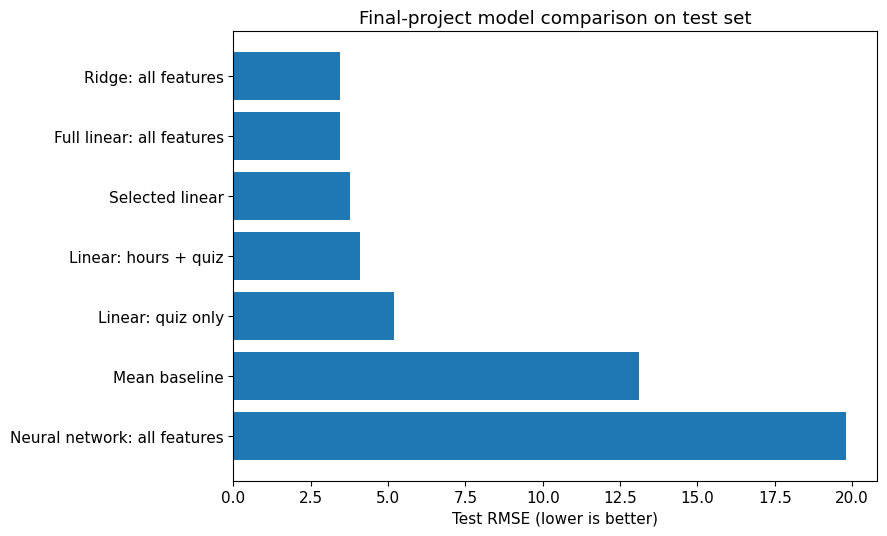

In [15]:
results_path = OUTPUTS_DIR / "model_comparison_test_set.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)

plot_df = results_df.sort_values("test_RMSE", ascending=False)
plt.figure(figsize=(9, 5.5))
plt.barh(plot_df["model"], plot_df["test_RMSE"])
plt.xlabel("Test RMSE (lower is better)")
plt.title("Final-project model comparison on test set")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_test_rmse.png", dpi=160)
plt.show()

## 11A. Coefficient comparison: full linear versus ridge

The ridge model uses the same candidate features as full linear regression, but it shrinks coefficient values. The plot below uses standardized predictors so the coefficient sizes are easier to compare.

When features are correlated, ordinary linear-regression coefficients can become unstable. Ridge reduces this instability by shrinking coefficients toward zero.

,feature,full_linear_standardized_coef,ridge_standardized_coef,absolute_shrinkage
0,hours_studied,3.512057,3.475253,0.036804
1,quiz_average,4.952522,4.833874,0.118648
2,attendance_rate,0.703580,0.702866,0.000714
3,assignments_submitted,1.500447,1.506515,-0.006068
4,login_count,-0.064912,0.022350,0.042562
5,previous_score,1.358587,1.410600,-0.052013
6,sleep_hours,0.783191,0.783931,-0.000740
7,screen_time_hours,-0.807048,-0.798367,0.008681


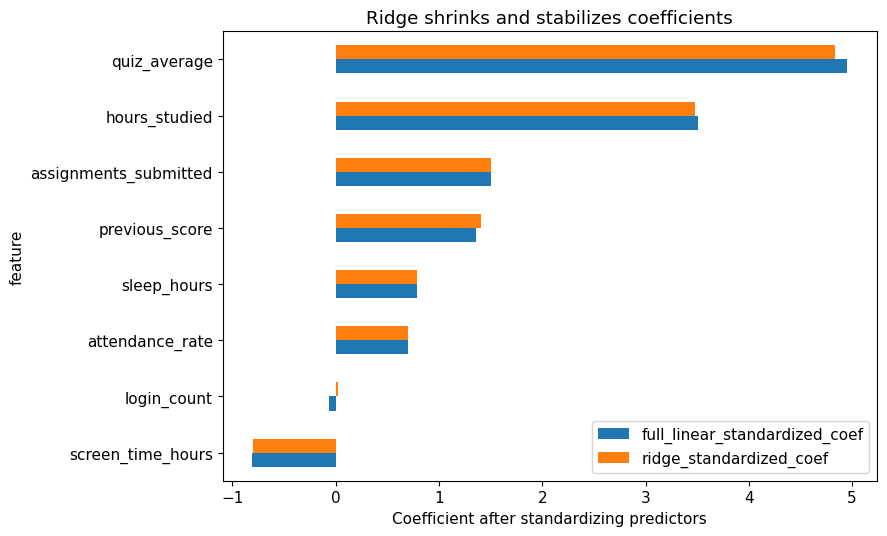

In [16]:
# Compare standardized coefficients for full linear regression and ridge regression.
standardized_linear = make_pipeline(StandardScaler(), LinearRegression())
standardized_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

standardized_linear.fit(trainval_df[feature_candidates], y_trainval)
standardized_ridge.fit(trainval_df[feature_candidates], y_trainval)

coef_compare = pd.DataFrame({
    "feature": feature_candidates,
    "full_linear_standardized_coef": standardized_linear.named_steps["linearregression"].coef_,
    "ridge_standardized_coef": standardized_ridge.named_steps["ridge"].coef_,
})
coef_compare["absolute_shrinkage"] = (
    coef_compare["full_linear_standardized_coef"].abs()
    - coef_compare["ridge_standardized_coef"].abs()
)

display(coef_compare)

coef_plot_df = coef_compare.set_index("feature")[["full_linear_standardized_coef", "ridge_standardized_coef"]]
coef_plot_df = coef_plot_df.sort_values("full_linear_standardized_coef")
ax = coef_plot_df.plot(kind="barh", figsize=(9, 5.5))
ax.set_xlabel("Coefficient after standardizing predictors")
ax.set_title("Ridge shrinks and stabilizes coefficients")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ridge_coefficient_comparison.png", dpi=160)
plt.show()

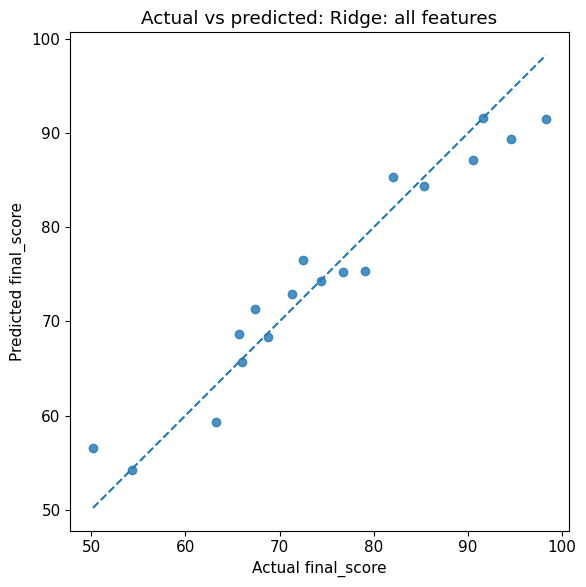

Best model on this test split: Ridge: all features


In [17]:
best_model_name = results_df.iloc[0]["model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.8)
min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual final_score")
plt.ylabel("Predicted final_score")
plt.title(f"Actual vs predicted: {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_predicted_best_model.png", dpi=160)
plt.show()

print("Best model on this test split:", best_model_name)

## 12. Interpret the winning model

Use this cell to generate a short conclusion based on the test results.

In [18]:
best_row = results_df.iloc[0]
conclusion = f"""
The best model on the test set is: {best_row['model']}.
Its test RMSE is {best_row['test_RMSE']:.3f}, and its test MAE is {best_row['test_MAE']:.3f}.
The baseline-relative R-squared is {best_row['test_R2_vs_baseline']:.3f}.

If the best model is ridge regression, explain it carefully:
- ridge is still a linear model;
- it adds an L2 penalty to shrink large coefficients;
- it can reduce variance when predictors are correlated;
- it can make the coefficient calculation more stable when X.T @ X is nearly singular.

This result should be compared with the mean baseline. A good final project explains not only
which model won, but why the result is believable, what features were useful, and what limitations remain.
"""
print(conclusion)


The best model on the test set is: Ridge: all features.
Its test RMSE is 3.439, and its test MAE is 2.704.
The baseline-relative R-squared is 0.931.

If the best model is ridge regression, explain it carefully:
- ridge is still a linear model;
- it adds an L2 penalty to shrink large coefficients;
- it can reduce variance when predictors are correlated;
- it can make the coefficient calculation more stable when X.T @ X is nearly singular.

This result should be compared with the mean baseline. A good final project explains not only
which model won, but why the result is believable, what features were useful, and what limitations remain.



## 13. Generate a final-project report template

This cell writes a Markdown file that students can edit into their final report.

In [19]:
report_text = f"""# Final Project Report Template

## 1. Project title
{project_title}

## 2. Project question
This project predicts `{target_col}` from candidate predictors such as {', '.join(feature_candidates[:4])}.

## 3. Data source
- File used: `{DATA_FILE}`
- Number of rows: {len(df)}
- Number of columns: {df.shape[1]}

## 4. Data dictionary
Fill in or revise this table for your own data.

| Column | Role | Meaning |
|---|---|---|
| {target_col} | target | value to predict |
| {feature_candidates[0]} | feature | candidate predictor |
| {feature_candidates[1]} | feature | candidate predictor |

## 5. EDA summary
- Missing values: write summary here.
- Important patterns: write one or two observations from plots.
- Possible problems: write one limitation or data issue.

## 6. Model comparison
The notebook compared baseline, linear, full linear, ridge, and neural-network candidates on the test set. Ridge regression is included because correlated predictors can make ordinary linear-regression coefficients unstable.

Best model in this run: **{best_row['model']}**

| Model | Test RMSE | Test MAE | R2 vs baseline |
|---|---:|---:|---:|
"""
for _, row in results_df.iterrows():
    report_text += f"| {row['model']} | {row['test_RMSE']:.3f} | {row['test_MAE']:.3f} | {row['test_R2_vs_baseline']:.3f} |\n"

report_text += """
## 7. Why ridge may be useful
Ridge regression adds an L2 penalty to shrink large coefficients. This can reduce variance and improve stability when predictors are correlated. If ridge wins, explain that it keeps all features while controlling coefficient instability.

## 8. Final decision
Explain which model you choose and why.

## 9. Limitations
Mention small data, missing variables, bias, overfitting, or measurement error.

## 10. Architecture plan
Describe the data layer, analysis layer, modeling layer, and delivery layer.

## 11. Next steps
What would improve the system after this course?
"""

report_path = OUTPUTS_DIR / "FINAL_PROJECT_REPORT_TEMPLATE.md"
report_path.write_text(report_text, encoding="utf-8")
print("Saved:", report_path)
print(report_text[:1200])

Saved: outputs/FINAL_PROJECT_REPORT_TEMPLATE.md
# Final Project Report Template

## 1. Project title
Student Success Prediction System

## 2. Project question
This project predicts `final_score` from candidate predictors such as hours_studied, quiz_average, attendance_rate, assignments_submitted.

## 3. Data source
- File used: `AKHU_lab6_final_project_student_success.csv`
- Number of rows: 120
- Number of columns: 10

## 4. Data dictionary
Fill in or revise this table for your own data.

| Column | Role | Meaning |
|---|---|---|
| final_score | target | value to predict |
| hours_studied | feature | candidate predictor |
| quiz_average | feature | candidate predictor |

## 5. EDA summary
- Missing values: write summary here.
- Important patterns: write one or two observations from plots.
- Possible problems: write one limitation or data issue.

## 6. Model comparison
The notebook compared baseline, linear, full linear, ridge, and neural-network candidates on the test set. Ridge regres

## 14. Generate an architecture blueprint template

This blueprint connects the data-analysis notebook to a software system design.

In [20]:
architecture_text = f"""# Architecture Blueprint Template

## System name
{project_title}

## Layer 1: Data layer
- Raw data file: `{DATA_FILE}`
- Target: `{target_col}`
- Candidate features: {', '.join(feature_candidates)}
- Validation checks: missing values, numeric types, expected ranges.

## Layer 2: Analysis layer
- EDA: target distribution, feature-target scatter plots, correlation heatmap.
- Split: train / validation / test.
- Variable selection: validation-based forward selection.

## Layer 3: Modeling layer
- Baseline: mean model.
- Candidate models: linear regression, selected linear regression, full linear regression, ridge regression with L2 penalty, neural network.
- Final test metric: RMSE, MAE, baseline-relative R2. Include a plain-language explanation if ridge is selected as the final model.

## Layer 4: Delivery layer
- Input: new data row as JSON.
- Output: predicted `{target_col}` and optional explanation.
- Possible API: `POST /predict`

## UML planning
### Use case diagram
- User requests prediction.
- Admin uploads data.
- Scheduler retrains model.

### Class diagram
- DataLoader
- DataValidator
- FeatureEngineer
- ModelTrainer
- ModelEvaluator
- ModelRegistry
- PredictionAPI

### Activity diagram
Data input -> validation -> EDA -> split -> train models -> validate/select -> test -> report.

### Deployment diagram
Client -> API server -> model artifact -> data storage -> monitoring logs.

## Risks and monitoring
- Data drift
- Missing feature values
- Prediction latency
- Model performance decline
"""

architecture_path = OUTPUTS_DIR / "ARCHITECTURE_BLUEPRINT_TEMPLATE.md"
architecture_path.write_text(architecture_text, encoding="utf-8")
print("Saved:", architecture_path)
print(architecture_text[:1200])

Saved: outputs/ARCHITECTURE_BLUEPRINT_TEMPLATE.md
# Architecture Blueprint Template

## System name
Student Success Prediction System

## Layer 1: Data layer
- Raw data file: `AKHU_lab6_final_project_student_success.csv`
- Target: `final_score`
- Candidate features: hours_studied, quiz_average, attendance_rate, assignments_submitted, login_count, previous_score, sleep_hours, screen_time_hours
- Validation checks: missing values, numeric types, expected ranges.

## Layer 2: Analysis layer
- EDA: target distribution, feature-target scatter plots, correlation heatmap.
- Split: train / validation / test.
- Variable selection: validation-based forward selection.

## Layer 3: Modeling layer
- Baseline: mean model.
- Candidate models: linear regression, selected linear regression, full linear regression, ridge regression with L2 penalty, neural network.
- Final test metric: RMSE, MAE, baseline-relative R2. Include a plain-language explanation if ridge is selected as the final model.

## Layer

## 15. Final project checklist

Before submission, check:

- [ ] The notebook runs from top to bottom.
- [ ] The dataset file is included.
- [ ] The target variable is clearly named.
- [ ] The features are explained.
- [ ] At least two EDA figures are included.
- [ ] A mean baseline is included.
- [ ] At least two candidate models are compared.
- [ ] If ridge regression is used, the L2 penalty and collinearity motivation are explained.
- [ ] Test-set performance is shown.
- [ ] The conclusion explains the model decision.
- [ ] The architecture blueprint is included.
- [ ] Limitations are stated honestly.